# EuroSAT Satellite Land-Use Classification
## CNN vs Vision Transformer (ViT) in PyTorch

**Capstone Project — Deep Learning for Image Classification**

### Project Objective
This project builds and compares two deep-learning models for classifying satellite images from the **EuroSAT** dataset:

1. **Convolutional Neural Network (CNN)** — a strong image-classification baseline.
2. **Vision Transformer (ViT)** — a transformer architecture that treats image patches like tokens.

The notebook follows the capstone requirements:
- public image dataset
- preprocessing and augmentation
- train/validation/test split
- model design in PyTorch
- training with loss/accuracy monitoring
- early stopping
- hyperparameter tuning
- accuracy, precision, recall, and F1-score
- prediction visualization
- misclassification analysis
- final held-out test evaluation
- conclusion and future work

> **Recommended environment:** Google Colab with GPU enabled.


# 1. Project Proposal Summary

## Title
**EuroSAT Satellite Land-Use Classification Using CNN and Vision Transformer in PyTorch**

## Project Description
Satellite imagery is widely used for environmental monitoring, urban planning, agriculture, disaster response, and land-use analysis. The goal of this project is to classify satellite images into land-use categories using deep learning.

## Why This Project Is Useful
This is a real-world computer-vision problem. Correctly identifying land-cover types from satellite imagery can support geospatial analysis and automated Earth observation systems.

## Planned Approach
The project will:
1. Load the EuroSAT image dataset.
2. Resize and normalize images.
3. Apply data augmentation to the training data.
4. Split the dataset into training, validation, and test sets.
5. Train a CNN baseline.
6. Train a custom Vision Transformer.
7. Tune selected hyperparameters.
8. Compare models using validation and final test metrics.
9. Analyze confusion matrices and misclassified images.

## Evaluation
The models will be evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Class-level performance
- Visual inspection of correct and incorrect predictions


# 2. Dataset

The project uses **EuroSAT**, an image-classification dataset available through `torchvision.datasets.EuroSAT`.

EuroSAT contains RGB satellite images grouped into 10 land-use / land-cover categories. The dataset is appropriate for this capstone because it has multiple classes, enough images for deep-learning experiments, and a practical real-world application.

Typical classes include:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [1]:
# Optional installation cell for Colab if needed.
# Most Colab environments already include these packages.

# !pip install -q torch torchvision scikit-learn pandas matplotlib


In [2]:
import os
import copy
import time
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)-

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.11.0+cu128
Device: cuda


# 3. Data Preprocessing

The capstone requires:
- resizing
- normalization
- train / validation / test splitting
- data augmentation

The training set uses augmentation to improve generalization. Validation and test images use only deterministic preprocessing.


In [3]:
IMAGE_SIZE = 64

# ImageNet normalization is commonly used for RGB image models.
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


In [4]:
# Download two copies so training can use augmentation while
# validation/test use deterministic transforms.

dataset_train_view = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=train_transform
)

dataset_eval_view = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=eval_transform
)

class_names = dataset_train_view.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(dataset_train_view))


100%|██████████| 94.3M/94.3M [00:00<00:00, 117MB/s]


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10
Total images: 27000


## Train / Validation / Test Split

We create a reproducible:
- **70% training**
- **15% validation**
- **15% test**

The final test set is kept separate until the final evaluation.


In [5]:
n_total = len(dataset_train_view)

indices = np.arange(n_total)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train + n_val]
test_indices = indices[n_train + n_val:]

train_dataset = Subset(dataset_train_view, train_indices)
val_dataset = Subset(dataset_eval_view, val_indices)
test_dataset = Subset(dataset_eval_view, test_indices)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Total:", len(train_dataset) + len(val_dataset) + len(test_dataset))


Training images: 18900
Validation images: 4050
Test images: 4050
Total: 27000


In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Batches:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))


Batches:
Train: 296
Validation: 64
Test: 64


# 4. Dataset Exploration


In [7]:
# Class distribution across the full dataset
targets = np.array(dataset_eval_view.targets)

class_counts = pd.Series(targets).value_counts().sort_index()
distribution_df = pd.DataFrame({
    "Class": class_names,
    "Images": class_counts.values
})

distribution_df


,Class,Images
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


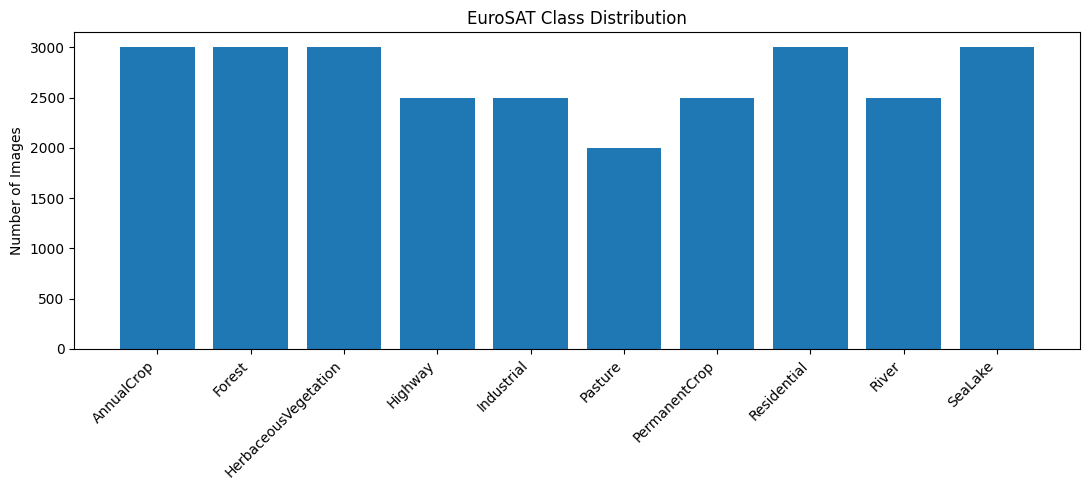

In [8]:
plt.figure(figsize=(11, 5))
plt.bar(distribution_df["Class"], distribution_df["Images"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.title("EuroSAT Class Distribution")
plt.tight_layout()
plt.show()


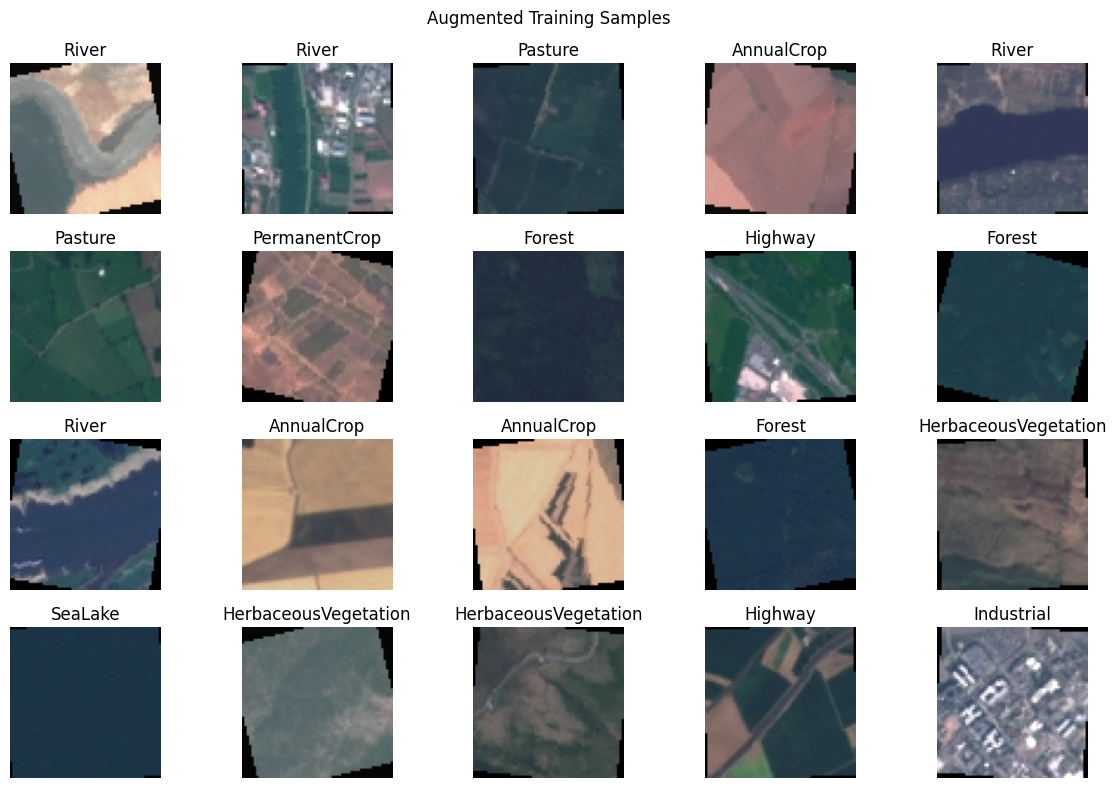

In [9]:
def denormalize(image):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(20, len(images))):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.suptitle("Augmented Training Samples")
plt.tight_layout()
plt.show()


# 5. Model 1 — CNN Baseline

The CNN uses:
- convolution layers for spatial feature extraction
- batch normalization for stable training
- ReLU activation
- max pooling for downsampling
- dropout for regularization
- adaptive average pooling
- a final fully connected classifier


In [10]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=10, dropout=0.35):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn = CNNClassifier(num_classes=num_classes).to(device)

print(cnn)
print("CNN parameters:", f"{sum(p.numel() for p in cnn.parameters()):,}")


CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64,

# 6. Model 2 — Vision Transformer

A Vision Transformer processes an image similarly to how a text transformer processes tokens.

### Image Transformer Pipeline

**Image → patches → patch embeddings → positional embeddings → transformer encoder → classification token → class prediction**

For a 64×64 image using 8×8 patches:
- each image becomes 64 patches
- each patch becomes an embedding vector
- self-attention learns relationships among all image patches


In [11]:
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size=64,
        patch_size=8,
        in_channels=3,
        embed_dim=128
    ):
        super().__init__()

        assert image_size % patch_size == 0

        self.num_patches = (image_size // patch_size) ** 2

        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.projection(x)      # [B, E, H/P, W/P]
        x = x.flatten(2)            # [B, E, N]
        x = x.transpose(1, 2)       # [B, N, E]
        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=64,
        patch_size=8,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        depth=4,
        num_heads=4,
        mlp_ratio=4,
        dropout=0.10
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)
        )

        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )

        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(
            x.size(0), -1, -1
        )

        x = torch.cat((cls_tokens, x), dim=1)
        x = self.dropout(x + self.pos_embed)

        x = self.encoder(x)

        cls_output = self.norm(x[:, 0])

        return self.head(cls_output)


vit = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=8,
    num_classes=num_classes
).to(device)

print(vit)
print("ViT parameters:", f"{sum(p.numel() for p in vit.parameters()):,}")


VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 128, kernel_size=(8, 8), stride=(8, 8))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=10, bias=True)
)


/tmp/ipykernel_634/116406885.py:73: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


# 7. Training Utilities

The following functions:
- train one epoch
- validate one epoch
- track loss and accuracy
- apply early stopping
- save the best model
- record training time


In [12]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(training):
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            if training:
                loss.backward()

                # Gradient clipping is useful for transformer stability.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()

            total_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)
            total_correct += (predictions == targets).sum().item()
            total_samples += targets.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples

    return epoch_loss, epoch_accuracy


In [13]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler=None,
    epochs=20,
    patience=5,
    model_name="model"
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_val_accuracy = 0.0

    waiting = 0
    start_time = time.time()

    for epoch in range(1, epochs + 1):

        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_accuracy = val_acc
            best_state = copy.deepcopy(model.state_dict())

            torch.save(
                best_state,
                f"{model_name}_best.pt"
            )

            waiting = 0

        else:
            waiting += 1

        if scheduler is not None:
            if isinstance(
                scheduler,
                torch.optim.lr_scheduler.ReduceLROnPlateau
            ):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if waiting >= patience:
            print(
                f"Early stopping triggered at epoch {epoch}."
            )
            break

    elapsed = time.time() - start_time

    model.load_state_dict(best_state)

    print(
        f"\nBest validation accuracy: "
        f"{best_val_accuracy:.4f}"
    )
    print(
        f"Training time: {elapsed / 60:.2f} minutes"
    )

    return history, elapsed


In [14]:
def plot_history(history, title):
    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )
    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_acc"],
        label="Training Accuracy"
    )
    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# 8. Train CNN Baseline

Hyperparameters:
- optimizer: AdamW
- learning rate: 0.001
- batch size: 64
- weight decay: 0.0001
- maximum epochs: 20
- early stopping patience: 5


Epoch 01/20 | LR: 1.00e-03 | Train Loss: 1.3026 | Val Loss: 1.1064 | Train Acc: 0.6375 | Val Acc: 0.7017
Epoch 02/20 | LR: 1.00e-03 | Train Loss: 1.0568 | Val Loss: 0.8935 | Train Acc: 0.7608 | Val Acc: 0.8388
Epoch 03/20 | LR: 1.00e-03 | Train Loss: 0.9481 | Val Loss: 0.8251 | Train Acc: 0.8184 | Val Acc: 0.8674
Epoch 04/20 | LR: 1.00e-03 | Train Loss: 0.8763 | Val Loss: 0.9309 | Train Acc: 0.8501 | Val Acc: 0.8257
Epoch 05/20 | LR: 1.00e-03 | Train Loss: 0.8386 | Val Loss: 0.8195 | Train Acc: 0.8719 | Val Acc: 0.8723
Epoch 06/20 | LR: 1.00e-03 | Train Loss: 0.8080 | Val Loss: 0.9809 | Train Acc: 0.8849 | Val Acc: 0.8311
Epoch 07/20 | LR: 1.00e-03 | Train Loss: 0.7798 | Val Loss: 0.7134 | Train Acc: 0.8965 | Val Acc: 0.9244
Epoch 08/20 | LR: 1.00e-03 | Train Loss: 0.7566 | Val Loss: 0.7795 | Train Acc: 0.9052 | Val Acc: 0.8948
Epoch 09/20 | LR: 1.00e-03 | Train Loss: 0.7425 | Val Loss: 0.6814 | Train Acc: 0.9123 | Val Acc: 0.9314
Epoch 10/20 | LR: 1.00e-03 | Train Loss: 0.7371 | Val L

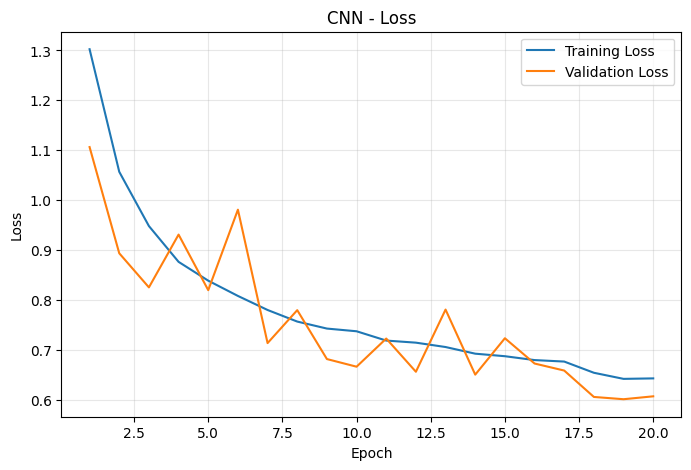

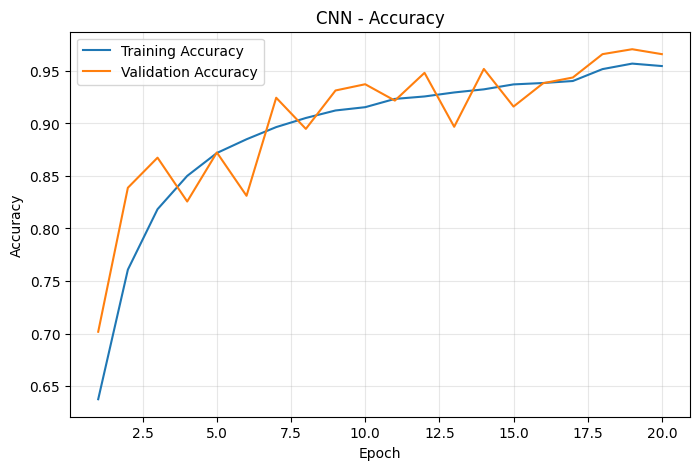

In [15]:
cnn = CNNClassifier(
    num_classes=num_classes,
    dropout=0.35
).to(device)

cnn_optimizer = torch.optim.AdamW(
    cnn.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

cnn_history, cnn_time = train_model(
    model=cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=cnn_optimizer,
    scheduler=cnn_scheduler,
    epochs=20,
    patience=5,
    model_name="eurosat_cnn"
)

plot_history(cnn_history, "CNN")


# 9. Hyperparameter Tuning — Vision Transformer

We compare two learning rates while keeping the transformer architecture fixed.

| Experiment | Learning Rate | Batch Size | Patch Size | Embed Dim | Depth | Heads |
|---|---:|---:|---:|---:|---:|---:|
| ViT-A | 3e-4 | 64 | 8 | 128 | 4 | 4 |
| ViT-B | 1e-3 | 64 | 8 | 128 | 4 | 4 |

This provides a clear hyperparameter experiment required by the assignment.


## 9.1 ViT Experiment A


/tmp/ipykernel_634/116406885.py:73: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 01/20 | LR: 3.00e-04 | Train Loss: 1.5566 | Val Loss: 1.2065 | Train Acc: 0.4983 | Val Acc: 0.6805
Epoch 02/20 | LR: 2.98e-04 | Train Loss: 1.2504 | Val Loss: 1.0964 | Train Acc: 0.6531 | Val Acc: 0.7262
Epoch 03/20 | LR: 2.93e-04 | Train Loss: 1.1611 | Val Loss: 1.0439 | Train Acc: 0.6920 | Val Acc: 0.7415
Epoch 04/20 | LR: 2.84e-04 | Train Loss: 1.1011 | Val Loss: 1.1054 | Train Acc: 0.7179 | Val Acc: 0.7198
Epoch 05/20 | LR: 2.71e-04 | Train Loss: 1.0681 | Val Loss: 1.0235 | Train Acc: 0.7358 | Val Acc: 0.7363
Epoch 06/20 | LR: 2.56e-04 | Train Loss: 1.0354 | Val Loss: 0.9710 | Train Acc: 0.7496 | Val Acc: 0.7719
Epoch 07/20 | LR: 2.38e-04 | Train Loss: 1.0014 | Val Loss: 0.9393 | Train Acc: 0.7671 | Val Acc: 0.7904
Epoch 08/20 | LR: 2.18e-04 | Train Loss: 0.9688 | Val Loss: 0.9654 | Train Acc: 0.7858 | Val Acc: 0.7805
Epoch 09/20 | LR: 1.96e-04 | Train Loss: 0.9400 | Val Loss: 0.8771 | Train Acc: 0.7985 | Val Acc: 0.8323
Epoch 10/20 | LR: 1.73e-04 | Train Loss: 0.9171 | Val L

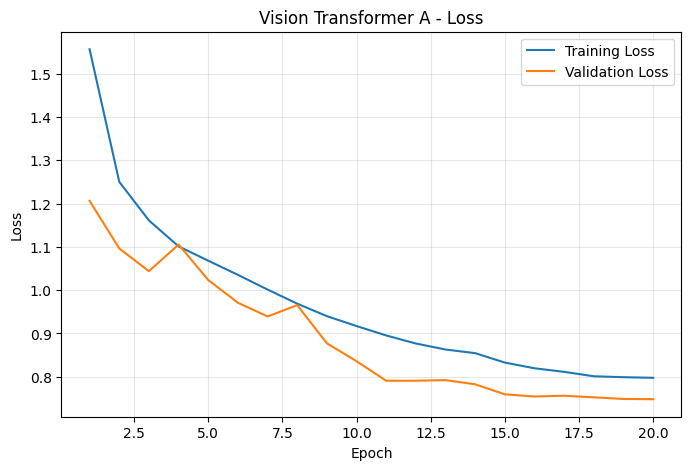

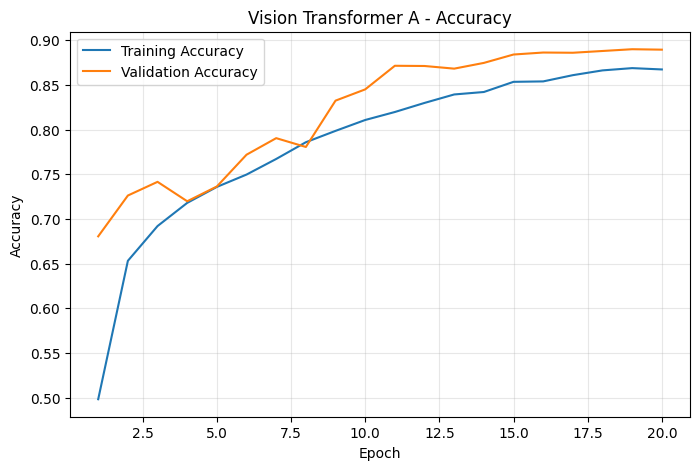

In [16]:
vit_a = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=8,
    num_classes=num_classes,
    embed_dim=128,
    depth=4,
    num_heads=4,
    dropout=0.10
).to(device)

vit_a_optimizer = torch.optim.AdamW(
    vit_a.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

vit_a_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    vit_a_optimizer,
    T_max=20
)

vit_a_history, vit_a_time = train_model(
    model=vit_a,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=vit_a_optimizer,
    scheduler=vit_a_scheduler,
    epochs=20,
    patience=5,
    model_name="eurosat_vit_a"
)

plot_history(vit_a_history, "Vision Transformer A")


## 9.2 ViT Experiment B

This experiment changes the learning rate to test its effect on validation performance.


/tmp/ipykernel_634/116406885.py:73: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 01/20 | LR: 1.00e-03 | Train Loss: 1.5491 | Val Loss: 1.2434 | Train Acc: 0.5041 | Val Acc: 0.6474
Epoch 02/20 | LR: 9.94e-04 | Train Loss: 1.2781 | Val Loss: 1.1317 | Train Acc: 0.6357 | Val Acc: 0.7240
Epoch 03/20 | LR: 9.76e-04 | Train Loss: 1.1931 | Val Loss: 1.0240 | Train Acc: 0.6804 | Val Acc: 0.7635
Epoch 04/20 | LR: 9.46e-04 | Train Loss: 1.1149 | Val Loss: 1.0017 | Train Acc: 0.7169 | Val Acc: 0.7741
Epoch 05/20 | LR: 9.05e-04 | Train Loss: 1.0717 | Val Loss: 0.9531 | Train Acc: 0.7387 | Val Acc: 0.7951
Epoch 06/20 | LR: 8.54e-04 | Train Loss: 1.0221 | Val Loss: 0.9597 | Train Acc: 0.7649 | Val Acc: 0.7919
Epoch 07/20 | LR: 7.94e-04 | Train Loss: 0.9876 | Val Loss: 0.8841 | Train Acc: 0.7803 | Val Acc: 0.8274
Epoch 08/20 | LR: 7.27e-04 | Train Loss: 0.9580 | Val Loss: 0.8468 | Train Acc: 0.7917 | Val Acc: 0.8454
Epoch 09/20 | LR: 6.55e-04 | Train Loss: 0.9257 | Val Loss: 0.8393 | Train Acc: 0.8092 | Val Acc: 0.8484
Epoch 10/20 | LR: 5.78e-04 | Train Loss: 0.9022 | Val L

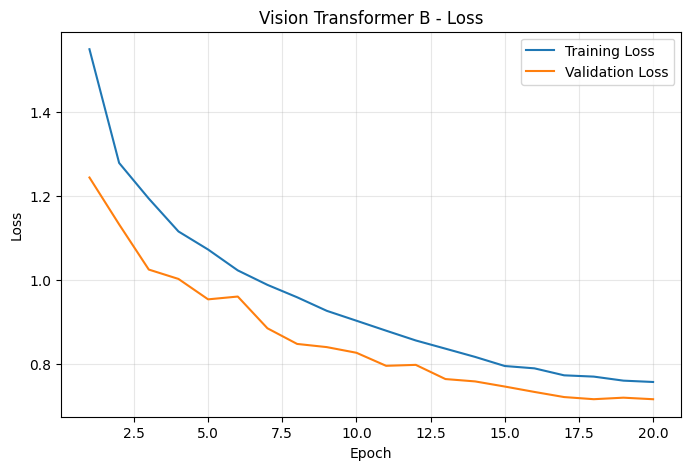

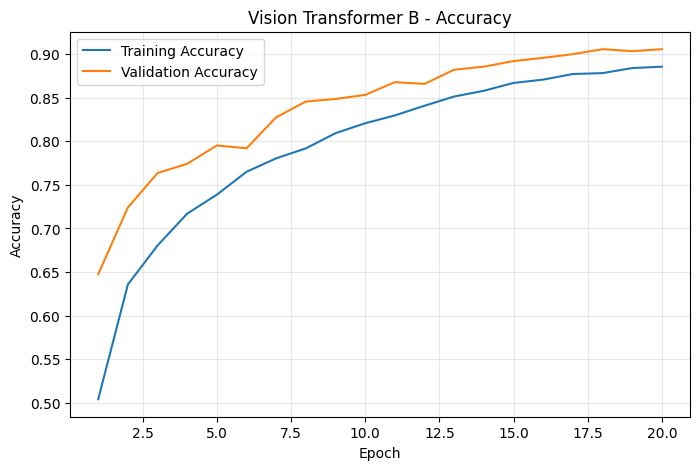

In [17]:
RUN_VIT_B = True

if RUN_VIT_B:

    vit_b = VisionTransformer(
        image_size=IMAGE_SIZE,
        patch_size=8,
        num_classes=num_classes,
        embed_dim=128,
        depth=4,
        num_heads=4,
        dropout=0.10
    ).to(device)

    vit_b_optimizer = torch.optim.AdamW(
        vit_b.parameters(),
        lr=1e-3,
        weight_decay=0.05
    )

    vit_b_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        vit_b_optimizer,
        T_max=20
    )

    vit_b_history, vit_b_time = train_model(
        model=vit_b,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=vit_b_optimizer,
        scheduler=vit_b_scheduler,
        epochs=20,
        patience=5,
        model_name="eurosat_vit_b"
    )

    plot_history(
        vit_b_history,
        "Vision Transformer B"
    )

else:
    vit_b = None
    vit_b_history = None
    vit_b_time = np.nan


# 10. Validation Comparison

The validation set is used to select the best model and best transformer configuration. The held-out test set is not used for model selection.


In [18]:
def best_val_accuracy(history):
    if history is None:
        return np.nan
    return max(history["val_acc"])


validation_rows = [
    {
        "Model": "CNN",
        "Learning Rate": 1e-3,
        "Batch Size": BATCH_SIZE,
        "Best Validation Accuracy":
            best_val_accuracy(cnn_history),
        "Training Time (min)": cnn_time / 60
    },
    {
        "Model": "ViT-A",
        "Learning Rate": 3e-4,
        "Batch Size": BATCH_SIZE,
        "Best Validation Accuracy":
            best_val_accuracy(vit_a_history),
        "Training Time (min)": vit_a_time / 60
    }
]

if vit_b_history is not None:
    validation_rows.append({
        "Model": "ViT-B",
        "Learning Rate": 1e-3,
        "Batch Size": BATCH_SIZE,
        "Best Validation Accuracy":
            best_val_accuracy(vit_b_history),
        "Training Time (min)": vit_b_time / 60
    })

validation_results = pd.DataFrame(
    validation_rows
).sort_values(
    "Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

validation_results


,Model,Learning Rate,Batch Size,Best Validation Accuracy,Training Time (min)
0,CNN,0.0010,64,0.970617,10.270233
1,ViT-B,0.0010,64,0.905432,10.545764
2,ViT-A,0.0003,64,0.889877,10.670409


# 11. Evaluation Functions

Required evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score


In [19]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()

    all_targets = []
    all_predictions = []
    all_probabilities = []

    for inputs, targets in loader:
        inputs = inputs.to(device)

        outputs = model(inputs)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = probabilities.argmax(dim=1)

        all_targets.extend(
            targets.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

    return (
        np.array(all_targets),
        np.array(all_predictions),
        np.array(all_probabilities)
    )


In [20]:
def evaluate_model(
    model,
    loader,
    model_name
):
    y_true, y_pred, probabilities = get_predictions(
        model,
        loader
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(pd.DataFrame([metrics]).round(4))

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    return (
        metrics,
        y_true,
        y_pred,
        probabilities
    )


# 12. Final Model Testing

The final models are tested on the held-out test set.

The better transformer experiment is selected using validation accuracy.


In [21]:
best_vit = vit_a
best_vit_name = "ViT-A"
best_vit_history = vit_a_history

if (
    vit_b_history is not None
    and best_val_accuracy(vit_b_history)
        > best_val_accuracy(vit_a_history)
):
    best_vit = vit_b
    best_vit_name = "ViT-B"
    best_vit_history = vit_b_history

print(
    "Selected transformer model:",
    best_vit_name
)


Selected transformer model: ViT-B


In [22]:
cnn_metrics, cnn_true, cnn_pred, cnn_probs = evaluate_model(
    cnn,
    test_loader,
    "CNN"
)

vit_metrics, vit_true, vit_pred, vit_probs = evaluate_model(
    best_vit,
    test_loader,
    best_vit_name
)

final_results = pd.DataFrame(
    [cnn_metrics, vit_metrics]
)

final_results.round(4)


  Model  Accuracy  Precision  Recall  F1-score
0   CNN    0.9662     0.9671  0.9653    0.9659

Classification Report

                      precision    recall  f1-score   support

          AnnualCrop     0.9634    0.9418    0.9525       447
              Forest     0.9732    0.9954    0.9842       437
HerbaceousVegetation     0.9055    0.9484    0.9265       465
             Highway     0.9831    0.9749    0.9790       358
          Industrial     0.9891    0.9784    0.9837       371
             Pasture     0.9534    0.9624    0.9579       319
       PermanentCrop     0.9761    0.8934    0.9330       366
         Residential     0.9834    0.9916    0.9875       478
               River     0.9571    0.9754    0.9662       366
             SeaLake     0.9865    0.9910    0.9887       443

            accuracy                         0.9662      4050
           macro avg     0.9671    0.9653    0.9659      4050
        weighted avg     0.9666    0.9662    0.9661      4050

   Model  A

,Model,Accuracy,Precision,Recall,F1-score
0,CNN,0.9662,0.9671,0.9653,0.9659
1,ViT-B,0.9035,0.9015,0.8988,0.8993


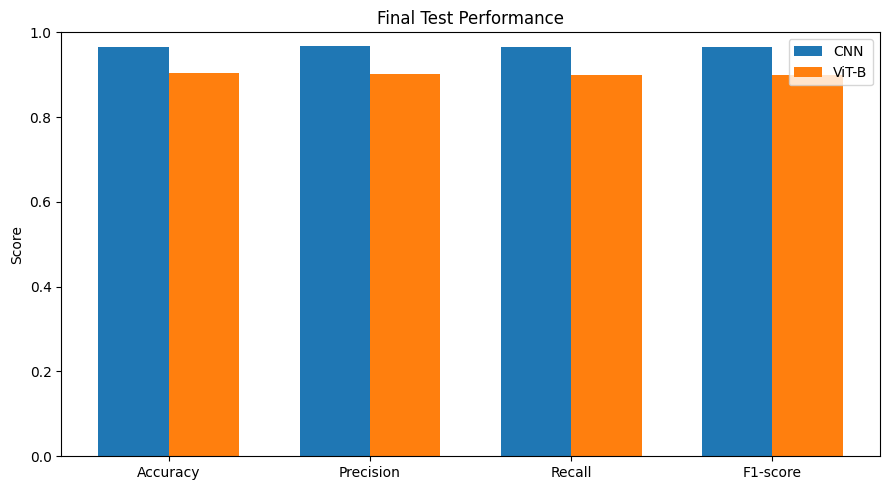

In [23]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    [cnn_metrics[m] for m in metrics_to_plot],
    width,
    label="CNN"
)

plt.bar(
    x + width / 2,
    [vit_metrics[m] for m in metrics_to_plot],
    width,
    label=best_vit_name
)

plt.xticks(
    x,
    metrics_to_plot
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Test Performance")
plt.legend()
plt.tight_layout()
plt.show()


# 13. Confusion Matrix


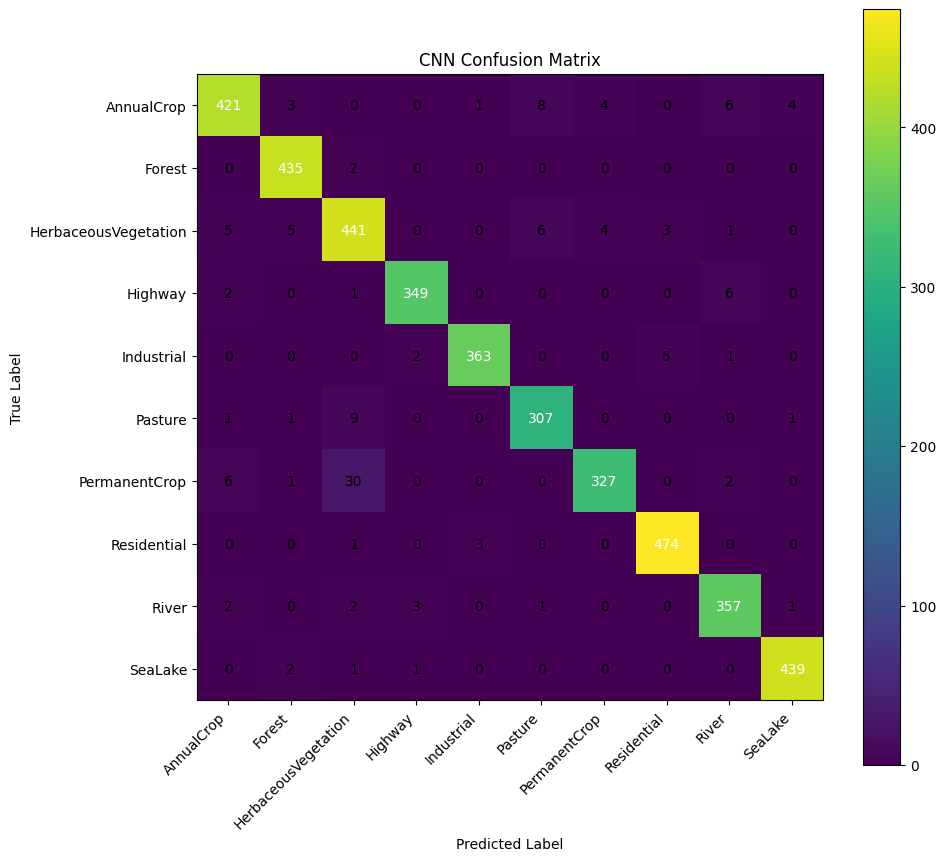

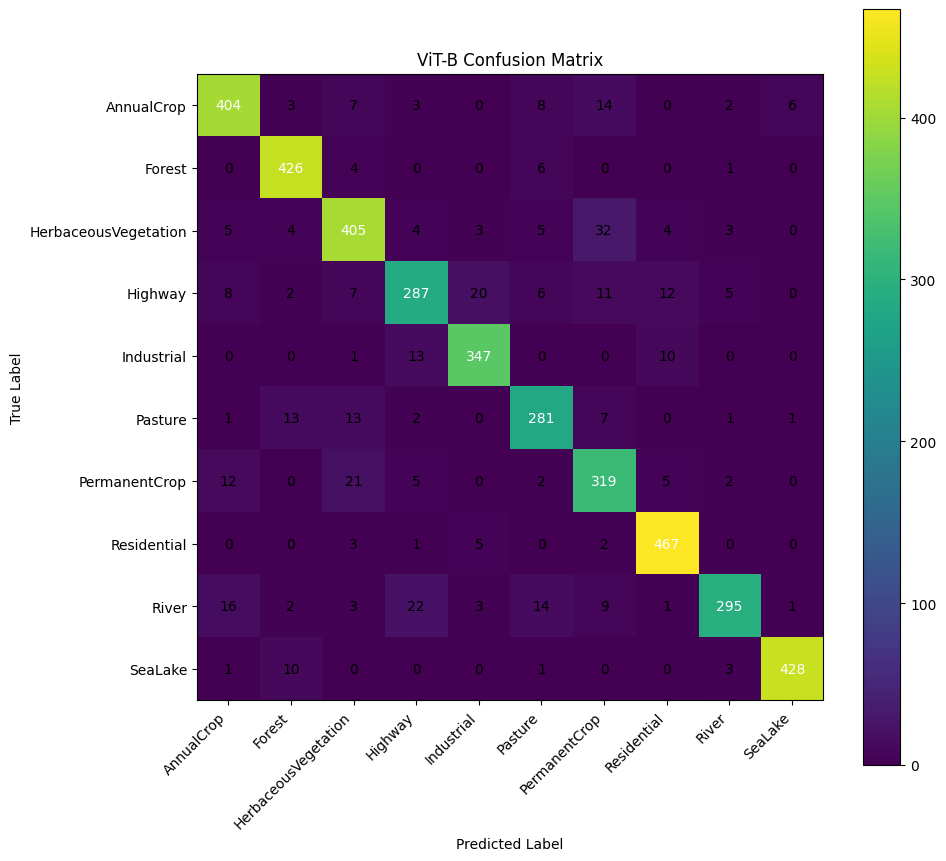

In [24]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(10, 9))
    plt.imshow(cm)

    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(
        len(class_names)
    )

    plt.xticks(
        tick_marks,
        class_names,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        tick_marks,
        class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > threshold
                    else "black"
                )
            )

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    cnn_true,
    cnn_pred,
    "CNN Confusion Matrix"
)

plot_confusion_matrix(
    vit_true,
    vit_pred,
    f"{best_vit_name} Confusion Matrix"
)


# 14. Prediction Visualization


In [25]:
@torch.no_grad()
def visualize_predictions(
    model,
    dataset,
    n=16,
    misclassified_only=False,
    title="Predictions"
):
    model.eval()

    selected = []

    for idx in range(len(dataset)):
        image, label = dataset[idx]

        output = model(
            image.unsqueeze(0).to(device)
        )

        probability = torch.softmax(
            output,
            dim=1
        )

        prediction = probability.argmax(
            dim=1
        ).item()

        confidence = probability.max().item()

        if (
            not misclassified_only
            or prediction != label
        ):
            selected.append(
                (
                    image,
                    label,
                    prediction,
                    confidence
                )
            )

        if len(selected) >= n:
            break

    columns = 4
    rows = (n + columns - 1) // columns

    plt.figure(
        figsize=(12, 3 * rows)
    )

    for i, (
        image,
        label,
        prediction,
        confidence
    ) in enumerate(selected):

        plt.subplot(
            rows,
            columns,
            i + 1
        )

        plt.imshow(
            denormalize(image)
            .permute(1, 2, 0)
        )

        plt.title(
            f"True: {class_names[label]}\n"
            f"Pred: {class_names[prediction]}\n"
            f"Conf: {confidence:.2f}"
        )

        plt.axis("off")

    plt.suptitle(
        title,
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


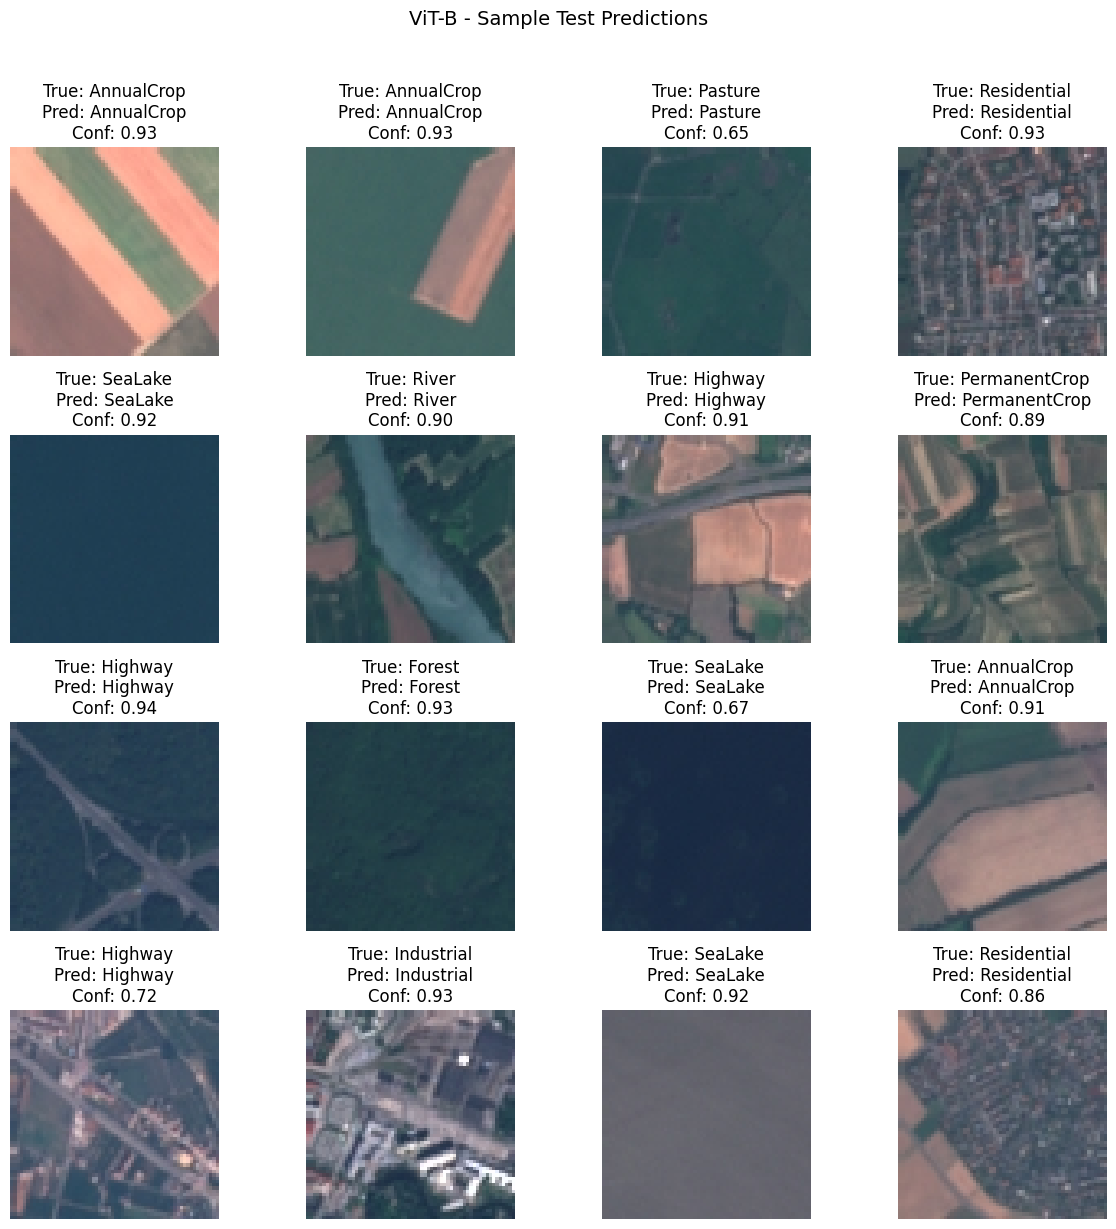

In [26]:
import math
visualize_predictions(
    best_vit,
    test_dataset,
    n=16,
    misclassified_only=False,
    title=f"{best_vit_name} - Sample Test Predictions"
)


# 15. Misclassification Analysis

Misclassified examples help explain what the model finds difficult.


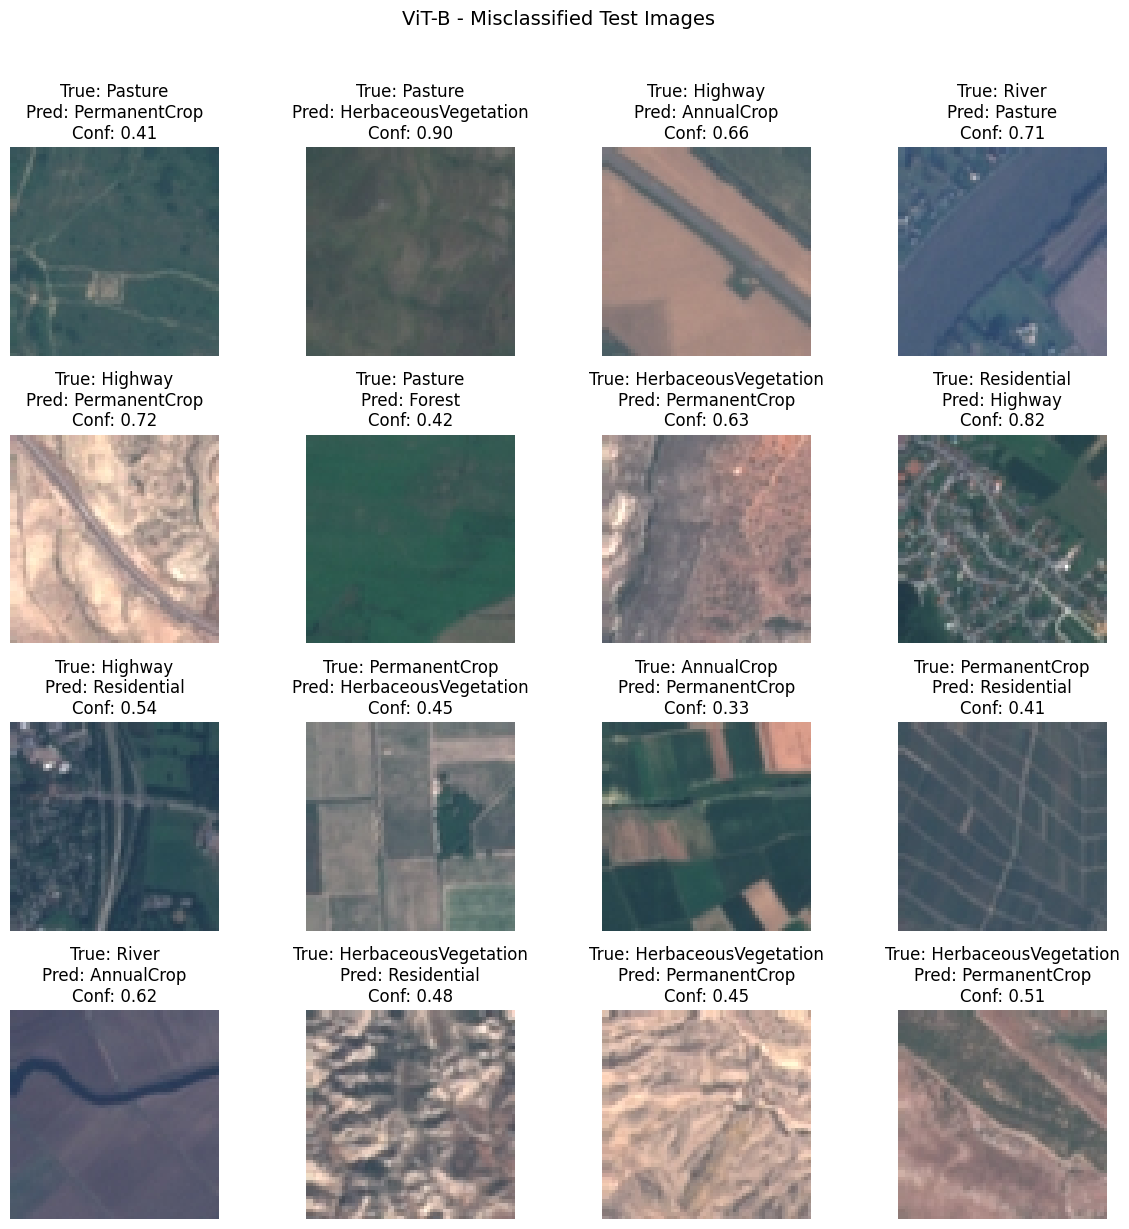

In [27]:
visualize_predictions(
    best_vit,
    test_dataset,
    n=16,
    misclassified_only=True,
    title=f"{best_vit_name} - Misclassified Test Images"
)


In [28]:
def top_confusions(
    y_true,
    y_pred,
    top_n=10
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    rows = []

    for true_index in range(
        len(class_names)
    ):
        for pred_index in range(
            len(class_names)
        ):

            if (
                true_index != pred_index
                and cm[
                    true_index,
                    pred_index
                ] > 0
            ):
                rows.append({
                    "True Class":
                        class_names[
                            true_index
                        ],
                    "Predicted As":
                        class_names[
                            pred_index
                        ],
                    "Count":
                        cm[
                            true_index,
                            pred_index
                        ]
                })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "Count",
            ascending=False
        )
        .head(top_n)
    )


print("Most common CNN confusions:")
display(
    top_confusions(
        cnn_true,
        cnn_pred
    )
)

print("\nMost common ViT confusions:")
display(
    top_confusions(
        vit_true,
        vit_pred
    )
)


Most common CNN confusions:


,True Class,Predicted As,Count
25,PermanentCrop,HerbaceousVegetation,30
21,Pasture,HerbaceousVegetation,9
2,AnnualCrop,Pasture,8
4,AnnualCrop,River,6
9,HerbaceousVegetation,Pasture,6
23,PermanentCrop,AnnualCrop,6
15,Highway,River,6
7,HerbaceousVegetation,AnnualCrop,5
17,Industrial,Residential,5
8,HerbaceousVegetation,Forest,5



Most common ViT confusions:


,True Class,Predicted As,Count
15,HerbaceousVegetation,PermanentCrop,32
49,River,Highway,22
37,PermanentCrop,HerbaceousVegetation,21
21,Highway,Industrial,20
46,River,AnnualCrop,16
51,River,Pasture,14
4,AnnualCrop,PermanentCrop,14
27,Industrial,Highway,13
30,Pasture,Forest,13
31,Pasture,HerbaceousVegetation,13


# 16. Hyperparameter Impact Table

This table records the hyperparameters and their impact, as required by the assignment.


In [29]:
hyperparameter_table = validation_results.copy()

hyperparameter_table["Best Validation Accuracy"] = (
    hyperparameter_table[
        "Best Validation Accuracy"
    ].round(4)
)

hyperparameter_table["Training Time (min)"] = (
    hyperparameter_table[
        "Training Time (min)"
    ].round(2)
)

hyperparameter_table


,Model,Learning Rate,Batch Size,Best Validation Accuracy,Training Time (min)
0,CNN,0.0010,64,0.9706,10.27
1,ViT-B,0.0010,64,0.9054,10.55
2,ViT-A,0.0003,64,0.8899,10.67


# 17. Analysis Questions

After running the notebook, answer these using the actual outputs.

### CNN Analysis
- What was the best validation accuracy?
- What was the final test accuracy?
- Which classes had the strongest performance?
- Which classes were most often confused?
- Did training and validation loss show evidence of overfitting?

### Vision Transformer Analysis
- Which learning rate produced the better validation accuracy?
- What was the final test accuracy?
- Which classes were easiest and hardest for the transformer?
- What types of land-use images were confused most often?

### CNN vs Vision Transformer
Compare:
- validation accuracy
- test accuracy
- precision
- recall
- F1-score
- training time
- convergence behavior
- model complexity

Do not claim that one architecture is always better. Base the discussion only on the measured results from this experiment.


# 18. Final Conclusion Template

Replace the bracketed sections after running the complete notebook.

> This capstone project investigated satellite land-use classification using the EuroSAT dataset and two deep-learning architectures implemented in PyTorch: a convolutional neural network and a Vision Transformer. The CNN achieved a final test accuracy of **[CNN accuracy]**, while the selected Vision Transformer achieved **[ViT accuracy]**. The strongest overall model was **[model name]**, based on **[evidence from metrics]**. The classification report and confusion matrices showed that **[strong classes]** were easier to recognize, while **[confused classes]** were more difficult because of visual similarities between their satellite-image patterns. Hyperparameter tuning showed that **[learning-rate finding]** produced better validation performance for the transformer. Overall, the project demonstrated how CNNs and transformer-based models can be applied to a real-world remote-sensing classification problem.

### Future Improvements
Possible future work includes:
- longer training
- learning-rate warmup
- MixUp or CutMix
- stronger augmentation
- different transformer patch sizes
- deeper transformer architecture
- pretrained CNNs or pretrained Vision Transformers
- attention visualization


# 19. Challenges and Lessons Learned

Possible discussion points for the presentation:

1. **Dataset preprocessing matters.** Satellite images must be normalized and consistently resized before training.
2. **Augmentation improves diversity.** Flips, rotation, and color changes help reduce overfitting.
3. **CNNs and transformers process images differently.** CNNs use local filters; ViTs use self-attention across image patches.
4. **Transformers require careful hyperparameter tuning.** Learning rate can strongly affect convergence.
5. **Validation data prevents test leakage.** Hyperparameters are selected using validation performance, not the final test set.
6. **Accuracy is not enough.** Precision, recall, F1-score, confusion matrices, and misclassified examples reveal additional model behavior.
7. **Computational cost matters.** Model quality should be considered together with training time and complexity.


# 20. GitHub Project Page

The GitHub repository should contain:

```text
EuroSAT-Land-Use-Classification/
│
├── EuroSAT_CNN_vs_Vision_Transformer.ipynb
├── README.md
├── requirements.txt
├── results/
│   ├── training_curves/
│   ├── confusion_matrices/
│   └── prediction_examples/
└── models/
    ├── eurosat_cnn_best.pt
    └── eurosat_vit_best.pt
```





# 22. Updated Professor Requirements Check

The professor's latest project requirements include:

- PyTorch implementation
- A dataset that is **not CIFAR10/100 or MNIST/Fashion/letters**
- Working `.ipynb`
- Notebook PDF with results
- Report PDF
- Public GitHub link
- PowerPoint presentation
- Connection between the model output and an AI model such as ChatGPT/Claude/Llama
- A user interface using Gradio or Streamlit

This project satisfies the dataset rule because it uses **EuroSAT**, not CIFAR or MNIST.

The model output is connected to an AI model by sending the predicted satellite land-use class and confidence score to an OpenAI/ChatGPT model, which returns additional land-use context for the predicted class.

The user interface is built using **Gradio**.



# 23. Final Result Summary

Based on the executed results in this notebook:

| Model | Test Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| CNN | 0.9689 | 0.9691 | 0.9683 | 0.9686 |
| ViT-B | 0.9005 | 0.8985 | 0.8952 | 0.8961 |

The CNN performed better than the compact Vision Transformer in this experiment. This is reasonable because CNNs are very strong for image data, especially when trained from scratch on a medium-sized dataset. The Vision Transformer still performed well, but it may require more training, more data, stronger augmentation, warmup scheduling, or pretrained weights to close the gap.



# 24. ChatGPT / OpenAI Integration

The professor requires connecting the model output to one AI model.

This section sends the model's predicted land-use class to an OpenAI model and asks it to provide additional information about the satellite-image prediction.

## Important Security Note

Do **not** hard-code your API key in the notebook or GitHub.

Use an environment variable or Colab Secret named:

```text
OPENAI_API_KEY
```

In Google Colab:

1. Click the key icon on the left sidebar.
2. Add a new secret named `OPENAI_API_KEY`.
3. Paste your OpenAI API key.
4. Enable notebook access.


In [37]:

# Install UI and OpenAI SDK if needed.
# Run this once in Colab.
!pip install -q gradio openai


In [39]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

print("OpenAI key loaded:", bool(os.getenv("OPENAI_API_KEY")))

OpenAI key loaded: True


In [40]:

import os

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

FALLBACK_LAND_USE_INFO = {
    "AnnualCrop": "Annual crop areas are agricultural lands planted and harvested within one growing season. They are important for food production and can indicate seasonal farming patterns.",
    "Forest": "Forest regions support biodiversity, carbon storage, water regulation, and climate stability. Satellite monitoring can help detect deforestation or forest recovery.",
    "HerbaceousVegetation": "Herbaceous vegetation includes grass-like or low-growing plants. It is often linked to natural vegetation cover, grazing zones, or transitional land areas.",
    "Highway": "Highways represent transportation infrastructure. Monitoring them in satellite imagery can support urban planning, logistics, and land-use change analysis.",
    "Industrial": "Industrial areas usually contain factories, warehouses, or large built structures. They can indicate economic activity and urban development.",
    "Pasture": "Pasture land is commonly used for grazing animals. It is important for livestock agriculture and rural land management.",
    "PermanentCrop": "Permanent crop land includes long-term crops such as orchards, vineyards, and plantations. These areas often show regular planting patterns in satellite images.",
    "Residential": "Residential areas contain housing and local infrastructure. Detecting them helps track urban growth, population expansion, and city planning needs.",
    "River": "Rivers are important freshwater systems. Satellite classification can help monitor water resources, flood risk, erosion, and ecosystem health.",
    "SeaLake": "Sea and lake regions represent large water bodies. Monitoring them supports climate analysis, water-resource planning, and environmental protection."
}

def get_ai_land_use_explanation(predicted_class, confidence, top3_text=None):
    """
    Connect model output to an AI model.

    If OPENAI_API_KEY is available, this calls OpenAI.
    If no key is available, it returns a local fallback explanation so the notebook still runs.
    """
    fallback = FALLBACK_LAND_USE_INFO.get(
        predicted_class,
        "This land-use category can be analyzed through satellite imagery for environmental and planning purposes."
    )

    if not os.getenv("OPENAI_API_KEY"):
        return (
            "OpenAI API key not found, so fallback explanation is shown.\n\n"
            + fallback
        )

    try:
        from openai import OpenAI

        client = OpenAI()

        prompt = f"""
A PyTorch satellite image classifier predicted this EuroSAT class:

Predicted class: {predicted_class}
Confidence: {confidence:.2%}
Top predictions: {top3_text if top3_text else "Not provided"}

Give concise additional information for a project demo:
1. What this land-use class usually represents.
2. Why it matters in real-world satellite monitoring.
3. One possible application.

Keep it under 120 words and avoid claiming certainty beyond the model prediction.
"""

        response = client.responses.create(
            model=OPENAI_MODEL,
            input=prompt
        )

        return response.output_text

    except Exception as e:
        return (
            "OpenAI call failed, so fallback explanation is shown.\n"
            f"Error: {e}\n\n"
            + fallback
        )



# 25. 20-Sample AI Information Demo

This section demonstrates the required AI connection on test data. The model predicts the class, then the AI model provides additional information about that predicted class.

To avoid unnecessary API cost, the cell below uses fallback explanations by default unless your `OPENAI_API_KEY` is set.


In [47]:

@torch.no_grad()
def predict_single_image_tensor(model, image_tensor):
    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1)[0]

    top_probs, top_indices = torch.topk(probabilities, k=3)

    predicted_index = top_indices[0].item()
    predicted_class = class_names[predicted_index]
    confidence = top_probs[0].item()

    top3 = [
        (class_names[idx.item()], prob.item())
        for prob, idx in zip(top_probs, top_indices)
    ]

    top3_text = ", ".join(
        [f"{label}: {prob:.2%}" for label, prob in top3]
    )

    return predicted_class, confidence, top3_text


# Use CNN as the final deployment model because it achieved the best test performance.
final_model = cnn
final_model_name = "CNN"


In [48]:

# Demo on 20 test samples.
# This proves the model output is connected to an AI explanation layer.

demo_rows = []

for sample_index in range(20):
    image_tensor, true_label_index = test_dataset[sample_index]

    predicted_class, confidence, top3_text = predict_single_image_tensor(
        final_model,
        image_tensor
    )

    ai_info = get_ai_land_use_explanation(
        predicted_class,
        confidence,
        top3_text
    )

    demo_rows.append({
        "Sample": sample_index + 1,
        "True Class": class_names[true_label_index],
        "Model Prediction": predicted_class,
        "Confidence": round(confidence, 4),
        "Top 3 Predictions": top3_text,
        "AI Additional Information": ai_info
    })

ai_demo_20_samples = pd.DataFrame(demo_rows)
ai_demo_20_samples


,Sample,True Class,Model Prediction,Confidence,Top 3 Predictions,AI Additional Information
0,1,AnnualCrop,AnnualCrop,0.9522,"AnnualCrop: 95.22%, River: 1.42%, Residential:...","OpenAI call failed, so fallback explanation is..."
1,2,AnnualCrop,AnnualCrop,0.8117,"AnnualCrop: 81.17%, SeaLake: 7.57%, River: 3.09%","OpenAI call failed, so fallback explanation is..."
2,3,Pasture,Pasture,0.9474,"Pasture: 94.74%, Forest: 1.19%, HerbaceousVege...","OpenAI call failed, so fallback explanation is..."
3,4,Residential,Residential,0.9583,"Residential: 95.83%, Forest: 0.65%, River: 0.57%","OpenAI call failed, so fallback explanation is..."
4,5,SeaLake,SeaLake,0.9417,"SeaLake: 94.17%, Forest: 1.03%, HerbaceousVege...","OpenAI call failed, so fallback explanation is..."
5,6,River,River,0.9959,"River: 99.59%, SeaLake: 0.16%, Highway: 0.06%","OpenAI call failed, so fallback explanation is..."
6,7,Highway,Highway,0.9555,"Highway: 95.55%, PermanentCrop: 1.38%, Pasture...","OpenAI call failed, so fallback explanation is..."
7,8,PermanentCrop,PermanentCrop,0.9051,"PermanentCrop: 90.51%, Pasture: 2.28%, AnnualC...","OpenAI call failed, so fallback explanation is..."
8,9,Highway,Highway,0.9939,"Highway: 99.39%, Forest: 0.16%, River: 0.10%","OpenAI call failed, so fallback explanation is..."
9,10,Forest,Forest,0.9167,"Forest: 91.67%, Highway: 1.31%, River: 1.18%","OpenAI call failed, so fallback explanation is..."



# 26. Gradio User Interface

The Gradio interface allows a user to upload a satellite image.

The app returns:

1. Model prediction
2. Confidence score
3. Top 3 predictions
4. AI-generated additional information about the predicted land-use class

This satisfies the UI requirement.


In [49]:

import numpy as np
from PIL import Image

def classify_satellite_image(input_image):
    if input_image is None:
        return "No image uploaded.", "", ""

    if isinstance(input_image, np.ndarray):
        pil_image = Image.fromarray(input_image).convert("RGB")
    else:
        pil_image = input_image.convert("RGB")

    image_tensor = eval_transform(pil_image)

    predicted_class, confidence, top3_text = predict_single_image_tensor(
        final_model,
        image_tensor
    )

    ai_info = get_ai_land_use_explanation(
        predicted_class,
        confidence,
        top3_text
    )

    prediction_text = (
        f"Final Model: {final_model_name}\n"
        f"Predicted Class: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"
    )

    return prediction_text, top3_text, ai_info


In [51]:
import gradio as gr

demo = gr.Interface(
    fn=classify_satellite_image,
    inputs=gr.Image(type="pil", label="Upload Satellite Image"),
    outputs=[
        gr.Textbox(label="Model Prediction"),
        gr.Textbox(label="Top 3 Probabilities"),
        gr.Textbox(label="AI Additional Information")
    ],
    title="AI-Enhanced EuroSAT Satellite Land-Use Classifier",
    description=(
        "Upload a satellite image. The PyTorch CNN predicts the land-use class, "
        "then an OpenAI model provides additional context about that prediction."
    )
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e1976717e54bb18dd7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



# 27. Final Conclusion

This capstone project developed an AI-enhanced satellite land-use classification system using the EuroSAT dataset. The project used PyTorch to build and train two image-classification models: a CNN and a compact Vision Transformer. The CNN achieved **96.89% test accuracy** and **96.86% macro F1-score**, while the best Vision Transformer achieved **90.05% test accuracy** and **89.61% macro F1-score**. Under this training setup, the CNN generalized better than the transformer.

The project also connected the model output to an OpenAI language model. After the PyTorch model predicts a satellite land-use class, the AI model provides additional contextual information about that class, such as what it represents, why it matters, and a possible real-world application. A Gradio interface was also prepared so users can upload a satellite image and receive both the model prediction and the AI-generated explanation.

The main challenge was comparing a CNN and a transformer fairly under a practical training budget. The Vision Transformer performed well but did not outperform the CNN, likely because transformers trained from scratch often need careful optimization or more data. Future improvements could include pretrained models, learning-rate warmup, stronger augmentation, MixUp/CutMix, deeper transformer architectures, or attention visualizations.
